# Synthetic Temporal Graph Notebook

This notebook is set up so that **only one cell needs to change** when you want to try a different synthetic dataset.

## Workflow
1. Edit the **generator cell** to create a new synthetic dataset.
2. Run the rest of the notebook unchanged.
3. The downstream cells will:
   - validate the generated data
   - visualize it
   - save it to JSON
   - load it through a PyTorch-compatible dataset class
   - show example timestep objects in the format your model expects

## Required output format from the generator cell
The generator cell must define a variable named `synthetic_data` with this structure:

```python
{
    "x_global": [[...], [...], ...],      # shape [num_nodes, embed_dim]
    "id_to_entity": {"0": "A0", ...},     # optional but recommended
    "id_to_rel": {"0": "rel1", "1": "rel2"},
    "timesteps": [
        {"edges": [{"src": 0, "dst": 10, "rel": 0}, ...]},
        {"edges": [...]},
        ...
    ]
}
```

Everything after the generator cell assumes only that format.


In [ ]:
# Imports and global config

from __future__ import annotations

import json
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Union

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import Tensor
from torch.utils.data import Dataset

SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)

OUT_DIR = Path("synthetic_data")
OUT_DIR.mkdir(exist_ok=True)

json_name = "3_stage_cascade.json"

JSON_PATH = OUT_DIR / json_name

print(f"Saving outputs under: {OUT_DIR.resolve()}")

Saving outputs under: C:\Users\jaden\OneDrive\Yale Classes\CPSC 4520\Temporal_Knowledge_Graph_GNN\data_exploration\synthetic_data


## Replace only this next cell when you want a different synthetic process

In [ ]:
# GENERATOR CELL
# Slightly harder synthetic dataset:
# - 3 node types: A, B, C
# - 4 relations:
#     0 = contact   (A -> B)
#     1 = bonded    (A -> B)
#     2 = signal    (B -> C)
#     3 = support   (B -> C)
# - derived relation:
#     4 = influence (A -> C), emitted when A->B is bonded and B->C is support at same timestep
#
# Temporal rules:
# 1. A-B lifecycle:
#    none -> contact for 2 -> bonded for 4 -> none, then cooldown
# 2. When an A-B pair first enters bonded, it can trigger B-C to start after a short delay
# 3. B-C lifecycle:
#    none -> signal for 1 -> support for 3 -> none, then cooldown
# 4. If bonded(A,B) and support(B,C) are both active at timestep t, emit influence(A,C)

NUM_A = 12
NUM_B = 10
NUM_C = 8
EMBED_DIM = 10
T = 300

P_AB_START = 0.035
P_TRIGGER_BC = 0.45

AB_COOLDOWN_STEPS = 3
BC_COOLDOWN_STEPS = 2

MAX_TRIGGER_DELAY = 3  # after AB enters bonded, BC may start 1..MAX_TRIGGER_DELAY steps later

# ----------------------------
# State encodings
# ----------------------------

# A -> B process
AB_NONE = 0
AB_CONTACT_1 = 1
AB_CONTACT_2 = 2
AB_BONDED_1 = 3
AB_BONDED_2 = 4
AB_BONDED_3 = 5
AB_BONDED_4 = 6

# B -> C process
BC_NONE = 0
BC_SIGNAL_1 = 1
BC_SUPPORT_1 = 2
BC_SUPPORT_2 = 3
BC_SUPPORT_3 = 4

A_nodes = [f"A{i}" for i in range(NUM_A)]
B_nodes = [f"B{i}" for i in range(NUM_B)]
C_nodes = [f"C{i}" for i in range(NUM_C)]
all_nodes = A_nodes + B_nodes + C_nodes

entity_to_id = {name: i for i, name in enumerate(all_nodes)}
id_to_entity = {i: name for name, i in entity_to_id.items()}

id_to_rel = {
    0: "contact",
    1: "bonded",
    2: "signal",
    3: "support",
    4: "influence",
}

node_types = {}
for name, idx in entity_to_id.items():
    node_types[idx] = name[0]

rng = np.random.default_rng(SEED)
x_global = rng.normal(size=(len(all_nodes), EMBED_DIM)).astype(np.float32)

# ----------------------------
# Hidden pair states
# ----------------------------
ab_state = np.zeros((NUM_A, NUM_B), dtype=np.int64)
ab_cooldown = np.zeros((NUM_A, NUM_B), dtype=np.int64)

bc_state = np.zeros((NUM_B, NUM_C), dtype=np.int64)
bc_cooldown = np.zeros((NUM_B, NUM_C), dtype=np.int64)

# delayed trigger queue for B->C starts
# trigger_queue[b, c] = number of steps until forced BC start, 0 means no pending trigger
trigger_queue = np.zeros((NUM_B, NUM_C), dtype=np.int64)

timesteps = []
meta_labels = []

for t in range(T):
    edges = []

    # Optional debugging label blocks
    ab_labels = np.zeros((NUM_A, NUM_B), dtype=np.int64)  # 0 none, 1 contact, 2 bonded
    bc_labels = np.zeros((NUM_B, NUM_C), dtype=np.int64)  # 0 none, 1 signal, 2 support
    ac_labels = np.zeros((NUM_A, NUM_C), dtype=np.int64)  # 0 none, 1 influence

    # ----------------------------
    # Emit A -> B edges
    # ----------------------------
    for i in range(NUM_A):
        for j in range(NUM_B):
            state = ab_state[i, j]
            src = entity_to_id[f"A{i}"]
            dst = entity_to_id[f"B{j}"]

            if state in (AB_CONTACT_1, AB_CONTACT_2):
                edges.append({"src": src, "dst": dst, "rel": 0})
                ab_labels[i, j] = 1
            elif state in (AB_BONDED_1, AB_BONDED_2, AB_BONDED_3, AB_BONDED_4):
                edges.append({"src": src, "dst": dst, "rel": 1})
                ab_labels[i, j] = 2

    # ----------------------------
    # Emit B -> C edges
    # ----------------------------
    for j in range(NUM_B):
        for k in range(NUM_C):
            state = bc_state[j, k]
            src = entity_to_id[f"B{j}"]
            dst = entity_to_id[f"C{k}"]

            if state == BC_SIGNAL_1:
                edges.append({"src": src, "dst": dst, "rel": 2})
                bc_labels[j, k] = 1
            elif state in (BC_SUPPORT_1, BC_SUPPORT_2, BC_SUPPORT_3):
                edges.append({"src": src, "dst": dst, "rel": 3})
                bc_labels[j, k] = 2

    # ----------------------------
    # Emit derived A -> C influence edges
    # ----------------------------
    for i in range(NUM_A):
        for j in range(NUM_B):
            ab_is_bonded = ab_state[i, j] in (AB_BONDED_1, AB_BONDED_2, AB_BONDED_3, AB_BONDED_4)
            if not ab_is_bonded:
                continue

            for k in range(NUM_C):
                bc_is_support = bc_state[j, k] in (BC_SUPPORT_1, BC_SUPPORT_2, BC_SUPPORT_3)
                if bc_is_support:
                    src = entity_to_id[f"A{i}"]
                    dst = entity_to_id[f"C{k}"]
                    edges.append({"src": src, "dst": dst, "rel": 4})
                    ac_labels[i, k] = 1

    timesteps.append({"edges": edges})
    meta_labels.append({
        "ab_labels": ab_labels.tolist(),
        "bc_labels": bc_labels.tolist(),
        "ac_labels": ac_labels.tolist(),
    })

    # ----------------------------
    # Advance A -> B process
    # ----------------------------
    next_ab_state = ab_state.copy()
    next_ab_cooldown = ab_cooldown.copy()

    for i in range(NUM_A):
        for j in range(NUM_B):
            state = ab_state[i, j]

            if state == AB_NONE:
                if ab_cooldown[i, j] > 0:
                    next_ab_cooldown[i, j] -= 1
                else:
                    if rng.random() < P_AB_START:
                        next_ab_state[i, j] = AB_CONTACT_1

            elif state == AB_CONTACT_1:
                next_ab_state[i, j] = AB_CONTACT_2

            elif state == AB_CONTACT_2:
                next_ab_state[i, j] = AB_BONDED_1

                # When AB first enters bonded, maybe trigger one or more BC futures from this B
                for k in range(NUM_C):
                    if bc_state[j, k] == BC_NONE and bc_cooldown[j, k] == 0 and trigger_queue[j, k] == 0:
                        if rng.random() < P_TRIGGER_BC:
                            trigger_queue[j, k] = rng.integers(1, MAX_TRIGGER_DELAY + 1)

            elif state == AB_BONDED_1:
                next_ab_state[i, j] = AB_BONDED_2
            elif state == AB_BONDED_2:
                next_ab_state[i, j] = AB_BONDED_3
            elif state == AB_BONDED_3:
                next_ab_state[i, j] = AB_BONDED_4
            elif state == AB_BONDED_4:
                next_ab_state[i, j] = AB_NONE
                next_ab_cooldown[i, j] = AB_COOLDOWN_STEPS

    # ----------------------------
    # Advance BC trigger queue
    # ----------------------------
    next_trigger_queue = trigger_queue.copy()
    for j in range(NUM_B):
        for k in range(NUM_C):
            if trigger_queue[j, k] > 0:
                next_trigger_queue[j, k] -= 1

    # ----------------------------
    # Advance B -> C process
    # ----------------------------
    next_bc_state = bc_state.copy()
    next_bc_cooldown = bc_cooldown.copy()

    for j in range(NUM_B):
        for k in range(NUM_C):
            state = bc_state[j, k]

            if state == BC_NONE:
                if bc_cooldown[j, k] > 0:
                    next_bc_cooldown[j, k] -= 1
                else:
                    # forced start from trigger queue when countdown hits zero
                    if trigger_queue[j, k] == 1:
                        next_bc_state[j, k] = BC_SIGNAL_1
                        next_trigger_queue[j, k] = 0

            elif state == BC_SIGNAL_1:
                next_bc_state[j, k] = BC_SUPPORT_1

            elif state == BC_SUPPORT_1:
                next_bc_state[j, k] = BC_SUPPORT_2
            elif state == BC_SUPPORT_2:
                next_bc_state[j, k] = BC_SUPPORT_3
            elif state == BC_SUPPORT_3:
                next_bc_state[j, k] = BC_NONE
                next_bc_cooldown[j, k] = BC_COOLDOWN_STEPS

    ab_state = next_ab_state
    ab_cooldown = next_ab_cooldown
    bc_state = next_bc_state
    bc_cooldown = next_bc_cooldown
    trigger_queue = next_trigger_queue

synthetic_data = {
    "x_global": x_global.tolist(),
    "id_to_entity": {str(k): v for k, v in id_to_entity.items()},
    "id_to_rel": {str(k): v for k, v in id_to_rel.items()},
    "node_types": {str(k): v for k, v in node_types.items()},
    "timesteps": timesteps,
    "label_matrices": meta_labels,  # richer debug labels than the simple case
    "meta": {
        "seed": SEED,
        "num_A": NUM_A,
        "num_B": NUM_B,
        "num_C": NUM_C,
        "embed_dim": EMBED_DIM,
        "T": T,
        "p_ab_start": P_AB_START,
        "p_trigger_bc": P_TRIGGER_BC,
        "ab_cooldown_steps": AB_COOLDOWN_STEPS,
        "bc_cooldown_steps": BC_COOLDOWN_STEPS,
        "max_trigger_delay": MAX_TRIGGER_DELAY,
    }
}

print("Generated synthetic_data")
print(f"num_nodes = {len(synthetic_data['x_global'])}")
print(f"num_relations = {len(synthetic_data['id_to_rel'])}")
print(f"num_timesteps = {len(synthetic_data['timesteps'])}")
print(f"timestep 0 edge count = {len(synthetic_data['timesteps'][0]['edges'])}")
print(f"timestep 10 edge count = {len(synthetic_data['timesteps'][10]['edges']) if T > 10 else 'n/a'}")

Generated synthetic_data
num_nodes = 40
num_relations = 2
num_timesteps = 500
timestep 0 edge count = 0


In [3]:
# Validation and quick summary

required_keys = {"x_global", "id_to_rel", "timesteps"}
missing = required_keys - set(synthetic_data.keys())
if missing:
    raise ValueError(f"synthetic_data missing required keys: {missing}")

xg = np.array(synthetic_data["x_global"], dtype=np.float32)
if xg.ndim != 2:
    raise ValueError(f"x_global must be 2D, got shape {xg.shape}")

num_nodes, embed_dim = xg.shape
num_timesteps = len(synthetic_data["timesteps"])
num_relations = len(synthetic_data["id_to_rel"])

print("Validation passed")
print(f"x_global shape: {xg.shape}")
print(f"num_relations:  {num_relations}")
print(f"num_timesteps:  {num_timesteps}")

edge_counts = [len(step.get("edges", [])) for step in synthetic_data["timesteps"]]
print(f"edge count range: {min(edge_counts)} .. {max(edge_counts)}")

Validation passed
x_global shape: (40, 8)
num_relations:  2
num_timesteps:  500
edge count range: 0 .. 117


In [4]:
# Save synthetic data to JSON

with open(JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(synthetic_data, f, indent=2)

print(f"Saved JSON to: {JSON_PATH.resolve()}")

Saved JSON to: C:\Users\jaden\OneDrive\Yale Classes\CPSC 4520\Temporal_Knowledge_Graph_GNN\data_exploration\synthetic_data\2ent_2rel_cyclic.json


In [8]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def plot_temporal_graphs_fixed(
    synthetic_data,
    timesteps=None,
    cols=3,
    figsize_per_plot=(7, 5),
    show_edge_labels=True,
):
    """
    Robust temporal graph plot:
    - automatically splits nodes into left/right columns based on edges
    - no overlap
    - clean spacing
    """

    id_to_entity = {int(k): v for k, v in synthetic_data["id_to_entity"].items()}
    id_to_rel = {int(k): v for k, v in synthetic_data["id_to_rel"].items()}
    steps = synthetic_data["timesteps"]

    if timesteps is None:
        timesteps = list(range(len(steps)))

    # ---- infer bipartite split from edges ----
    left_nodes = set()
    right_nodes = set()

    for step in steps:
        for e in step.get("edges", []):
            left_nodes.add(int(e["src"]))
            right_nodes.add(int(e["dst"]))

    # fallback: if no edges, just split by half
    if not left_nodes and not right_nodes:
        nodes = sorted(id_to_entity.keys())
        mid = len(nodes) // 2
        left_nodes = set(nodes[:mid])
        right_nodes = set(nodes[mid:])

    left_nodes = sorted(left_nodes)
    right_nodes = sorted(right_nodes)

    # ---- fixed positions ----
    pos = {}

    def spread(nodes, x):
        n = len(nodes)
        ys = np.linspace(n/2, -n/2, n)
        for i, node in enumerate(nodes):
            pos[node] = (x, ys[i])

    spread(left_nodes, x=0)
    spread(right_nodes, x=3)

    # ---- colors ----
    node_colors = {}
    for n in left_nodes:
        node_colors[n] = "skyblue"
    for n in right_nodes:
        node_colors[n] = "lightgreen"

    rel_colors = {}
    palette = ["red", "blue", "green", "purple", "orange"]
    for i, rel in enumerate(sorted(id_to_rel.keys())):
        rel_colors[rel] = palette[i % len(palette)]

    # ---- plotting ----
    n = len(timesteps)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*figsize_per_plot[0], rows*figsize_per_plot[1]))

    if rows == 1:
        axes = axes if isinstance(axes, list) else list(np.atleast_1d(axes))
    else:
        axes = axes.flatten()

    for i, t in enumerate(timesteps):
        ax = axes[i]
        step = steps[t]

        G = nx.DiGraph()

        for nid, name in id_to_entity.items():
            G.add_node(nid)

        for e in step.get("edges", []):
            src = int(e["src"])
            dst = int(e["dst"])
            rel = int(e["rel"])
            G.add_edge(src, dst, rel=rel)

        # nodes
        nx.draw_networkx_nodes(
            G, pos,
            node_color=[node_colors[n] for n in G.nodes()],
            node_size=1000,
            edgecolors="black",
            ax=ax
        )

        # labels
        nx.draw_networkx_labels(
            G, pos,
            labels=id_to_entity,
            font_size=8,
            ax=ax
        )

        # edges by relation
        for rel in rel_colors:
            edges = [(u, v) for u, v, d in G.edges(data=True) if d["rel"] == rel]
            if edges:
                nx.draw_networkx_edges(
                    G, pos,
                    edgelist=edges,
                    edge_color=rel_colors[rel],
                    width=2,
                    ax=ax
                )

        # edge labels
        if show_edge_labels:
            edge_labels = {(u, v): id_to_rel[d["rel"]] for u, v, d in G.edges(data=True)}
            nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, ax=ax)

        ax.set_title(f"Timestep {t}")
        ax.axis("off")

    for j in range(len(timesteps), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

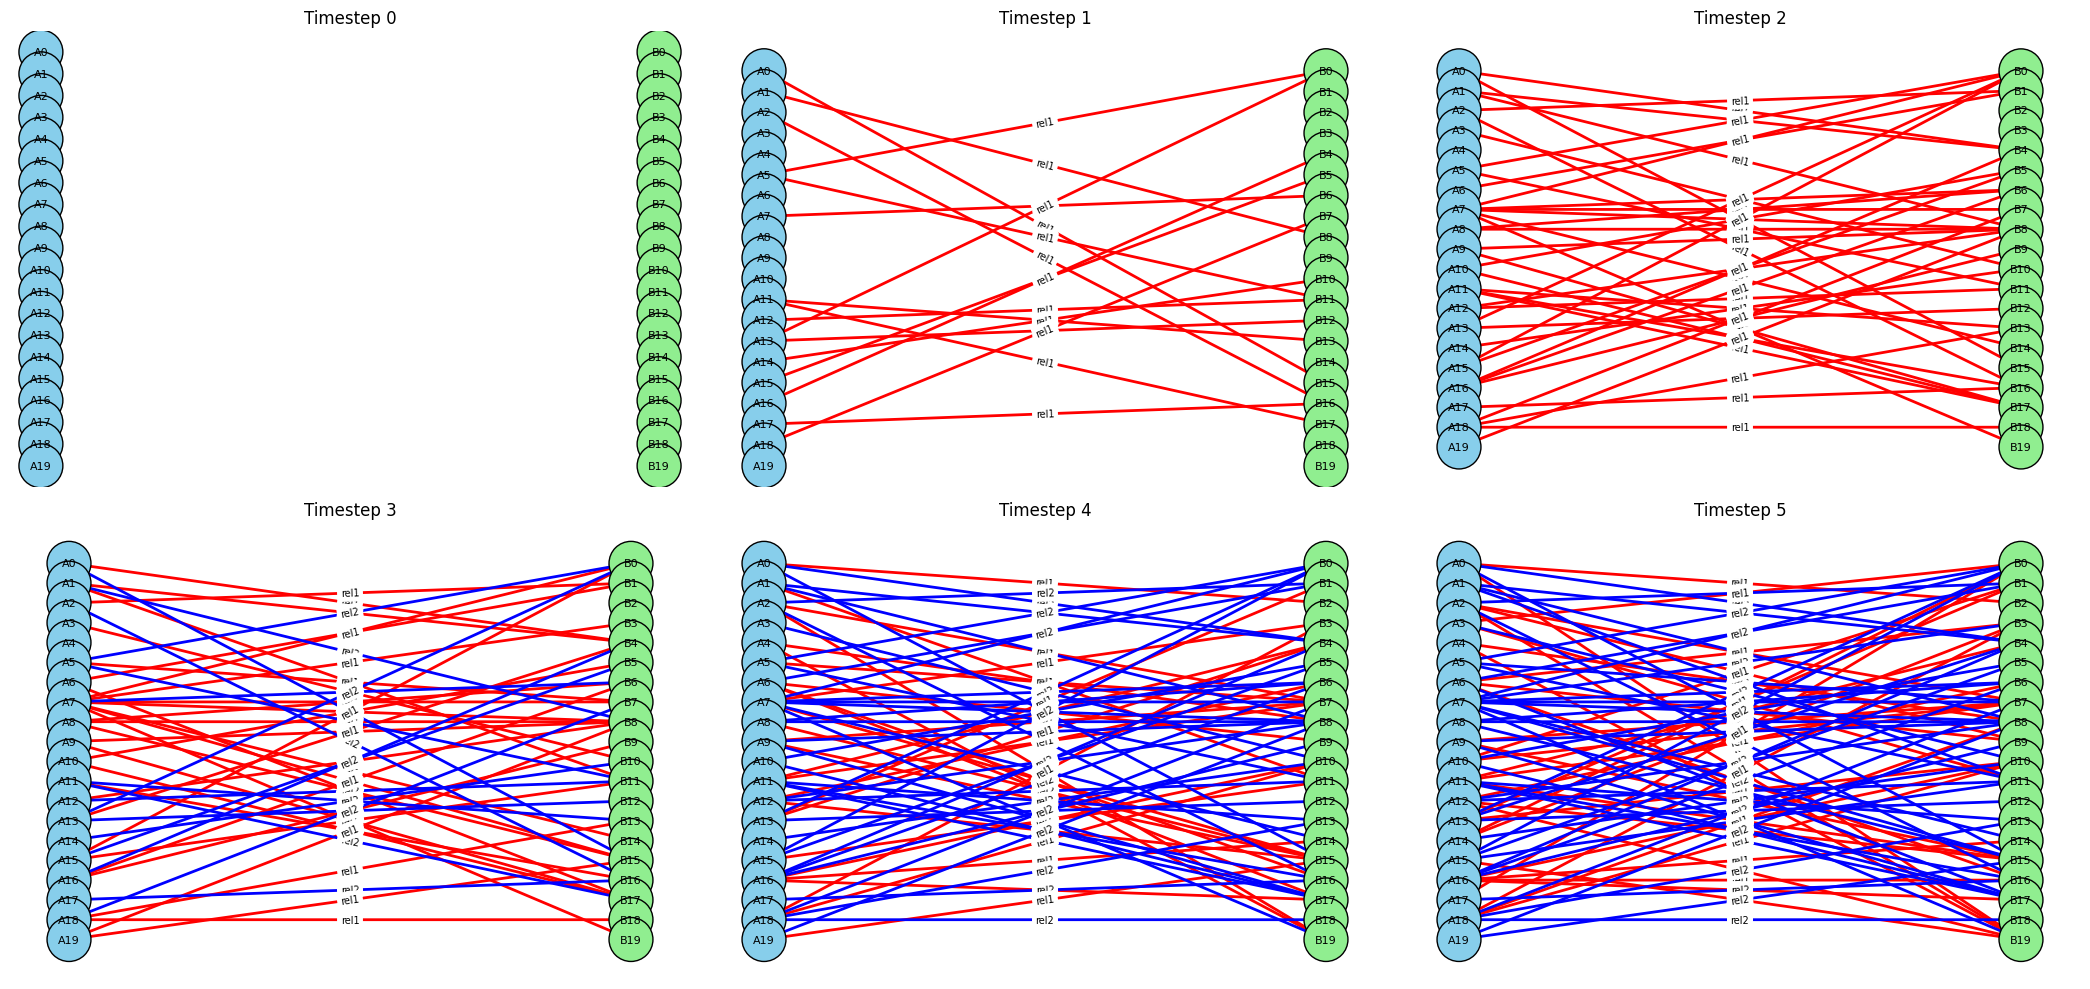

In [9]:
plot_temporal_graphs_fixed(synthetic_data, timesteps=[0, 1, 2, 3, 4, 5])